Model: DecisionTreeClassifier
-----------------Train metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       146
           1       1.00      1.00      1.00       118
           2       1.00      1.00      1.00      2703

    accuracy                           1.00      2967
   macro avg       1.00      1.00      1.00      2967
weighted avg       1.00      1.00      1.00      2967
 

-----------------Test metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       0.98      1.00      0.99        49
           1       1.00      0.97      0.99        39
           2       1.00      1.00      1.00       902

    accuracy                           1.00       990
   macro avg       0.99      0.99      0.99       990
weighted avg       1.00      1.00      1.00       990
 


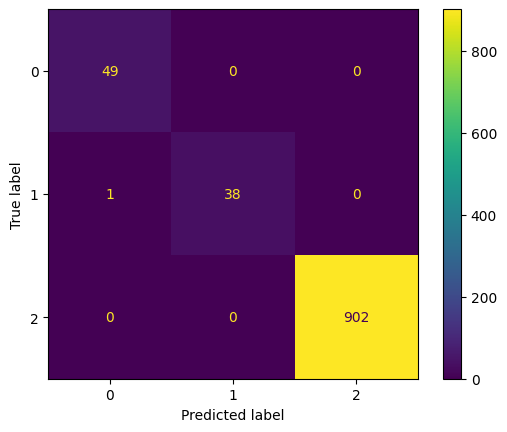




Model: RandomForestClassifier
-----------------Train metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       146
           1       1.00      1.00      1.00       118
           2       1.00      1.00      1.00      2703

    accuracy                           1.00      2967
   macro avg       1.00      1.00      1.00      2967
weighted avg       1.00      1.00      1.00      2967
 

-----------------Test metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       0.98      1.00      0.99        49
           1       1.00      0.97      0.99        39
           2       1.00      1.00      1.00       902

    accuracy                           1.00       990
   macro avg       0.99      0.99      0.99       990
weighted avg       1.00      1.00      1.00       990
 


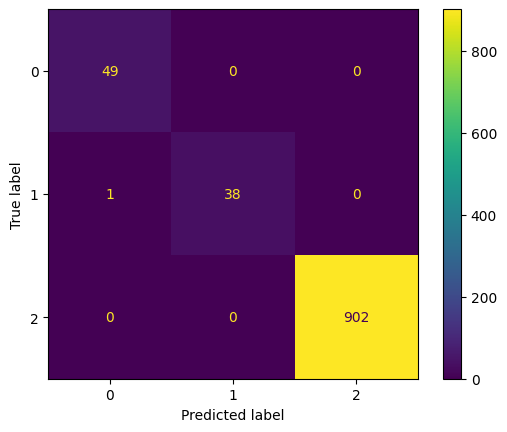




Model: XGBClassifier
-----------------Train metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98       146
           1       0.97      0.95      0.96       118
           2       1.00      1.00      1.00      2703

    accuracy                           1.00      2967
   macro avg       0.98      0.98      0.98      2967
weighted avg       1.00      1.00      1.00      2967
 

-----------------Test metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       0.94      1.00      0.97        49
           1       0.95      0.92      0.94        39
           2       1.00      1.00      1.00       902

    accuracy                           0.99       990
   macro avg       0.96      0.97      0.97       990
weighted avg       1.00      0.99      0.99       990
 


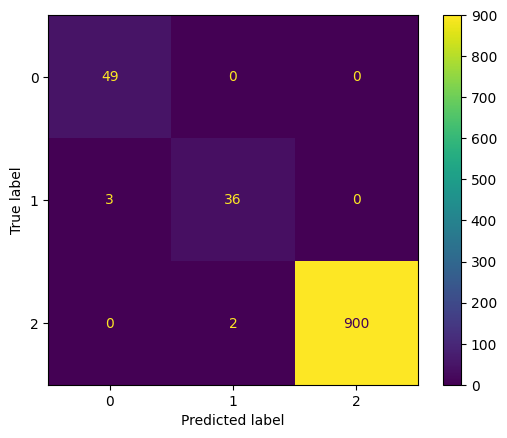




Model: LGBMClassifier
-----------------Train metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       1.00      0.98      0.99       146
           1       0.98      1.00      0.99       118
           2       1.00      1.00      1.00      2703

    accuracy                           1.00      2967
   macro avg       0.99      0.99      0.99      2967
weighted avg       1.00      1.00      1.00      2967
 

-----------------Test metrics-----------------
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        39
           2       1.00      1.00      1.00       902

    accuracy                           1.00       990
   macro avg       1.00      1.00      1.00       990
weighted avg       1.00      1.00      1.00       990
 


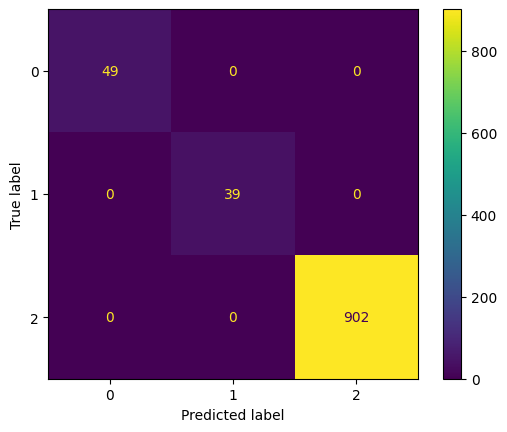




The choosen model was: LGBMClassifier(verbose=-1) with 1.00 of accuracy.


In [35]:
# Get the data

import pandas as pd
df = pd.read_csv('../../../datasets/manufacturing.csv')

X = df.drop(columns= ['Quality Rating', 'Pressure (kPa)', 'Temperature x Pressure', 'Material Fusion Metric'])
df['Quality Rating'] = pd.cut(df['Quality Rating'], bins=[-1, 70, 90, 100] , labels=[0,1,2])
y = df[['Quality Rating']].astype(int)

# Split the data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state=42, stratify=y)

# Preprocessing 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


# Models
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
models = [ DecisionTreeClassifier(max_depth=10), RandomForestClassifier(max_depth=10, n_estimators = 150), XGBClassifier(), LGBMClassifier(verbose = -1)]


# Train
for model in models:
    # Get the model name's
    print(f"======================================================")
    print(f"Model: {model.__class__.__name__}")

    # Pipeline for the algorithm
    pipe = Pipeline(
        steps=[("Scaler", scaler),
               ("Model", model)])

    # Creathe the train logic
    best_model = {}
    pipe.fit(X_train, y_train)

    # Check if overfitting and metrics for test
    y_preds_train = pipe.predict(X_train)
    y_preds_test = pipe.predict(X_test)

    #See metrics
    from sklearn.metrics import classification_report, ConfusionMatrixDisplay
    
    # Ignore warning
    import warnings
    warnings.filterwarnings('ignore')

    # Train
    cr = classification_report(y_train, y_preds_train)
    print(f"-----------------Train metrics-----------------")
    print(f"Classification Report: {cr} ")
    print()

    # Test
    cr = classification_report(y_test, y_preds_test)
    cm = ConfusionMatrixDisplay.from_predictions(y_test, y_preds_test)  
    print(f"-----------------Test metrics-----------------")
    print(f"Classification Report: {cr} ")
    import matplotlib.pyplot as plt
    plt.show()

    # Add the model for the list
    cr = classification_report(y_test, y_preds_test, output_dict=True)
    best_model[f"{model}"] = [cr, cm]
    print(f'\n\n')

# Choose the best model

for model, metrics in best_model.items():
    best_accuracy = 0
    selected_model_name = ""
    current_accuracy = metrics[0]['accuracy'] 
    
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        selected_model_name = model
    print(f"The choosen model was: {selected_model_name} with {best_accuracy:.2f} of accuracy.")
